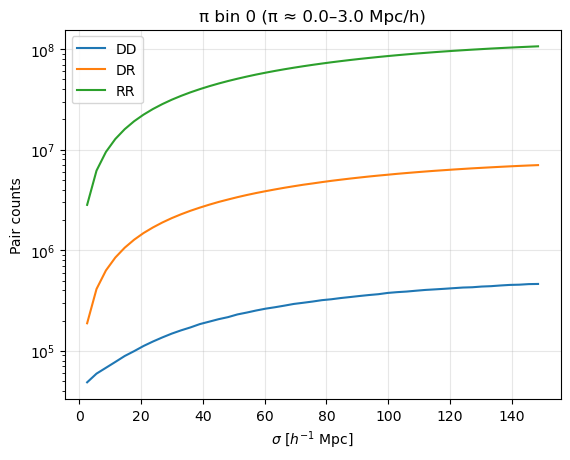

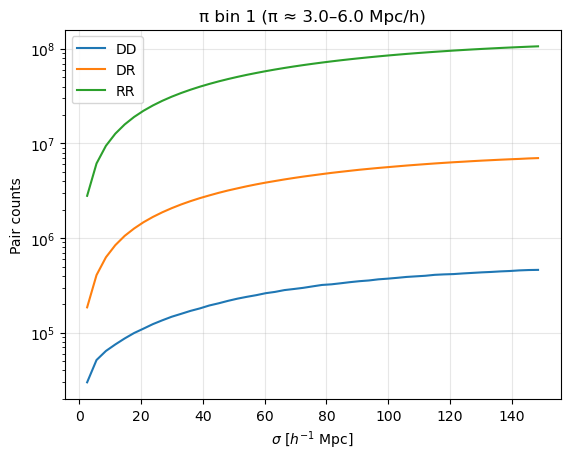

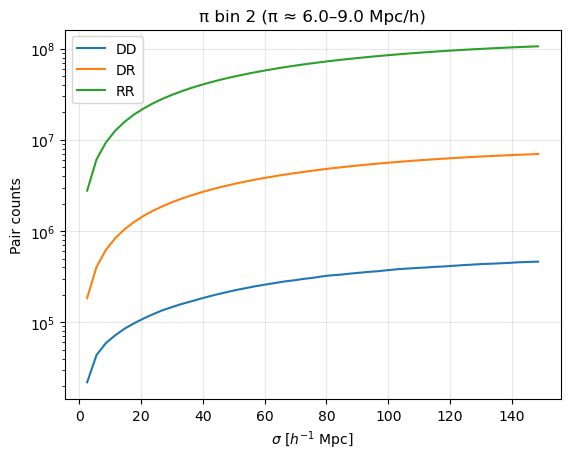

WD = 7.51e+04, WR = 1.13e+06, factor = WD/WR = 0.0667
Expected factor ≈ 1 / nrand_mult = 1/15 ≈ 0.0667 (if nrand_mult=15 and no weights)
Sum of RR pairs: 1.36e+11, WR**2 = 1.27e+12


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import os
def get_paircounts_filename(bin_name, params):
    """
    Generate a filename for saved pair counts based on key parameters.
    params should be a dict containing at least:
        sample, sigma, h, zmin, zmax, mag_max, gr_min,
        min_sep_2d, max_sep_2d, bin_size_2d, pi_rebin,
        nrand_mult, ran_radec_method, and the bin identifier (bin_name).
    """
    # Create a string with all relevant values
    parts = [
        f"z={params['zmin']:.2f}-{params['zmax']:.2f}",
        f"mag={params['mag_max']:.1f}",
        f"gr={params['gr_min']:.1f}",
        f"sep={params['min_sep_2d']}-{params['max_sep_2d']}",
        f"bin={params['bin_size_2d']}",
        f"pi_rebin={params['pi_rebin']}",
        f"nrand={params['nrand_mult']}",
        f"radec={params['ran_radec_method']}",
        f"bin={bin_name}",
        f"distbinmode={params['dist_bin_mode']}"
    ]
    # Join and replace dots to avoid filesystem issues
    fname = "_".join(parts).replace('.', 'p')
    return os.path.join('../data/pair_counts', fname + ".npz")

base_params = {
    'zmin': .07,
    'zmax': 0.2,
    'mag_max': -21.2,
    'gr_min': 0.0,
    'min_sep_2d': 1.0,
    'max_sep_2d': 150.0,
    'bin_size_2d': 3.0,
    'pi_rebin': 3,
    'nrand_mult': 15,
    'ran_radec_method': 'file'
}

# --- Full sample (dist_bin_mode fixed to 'full') ---
params_full = base_params.copy()
params_full['dist_bin_mode'] = 'full'   # constant placeholder
paircounts_file_full = get_paircounts_filename("full", params_full)

# Path to one of the saved .npz files (full sample or bin)
npz_file = paircounts_file_full   # change to your actual file

data = np.load(npz_file)

# Extract needed arrays
rp_bins = data['rp_bins']              # σ bin edges (length nσ+1)
H_dd = data['H_dd_rebinned']          # shape: (nσ, nπ_rebinned)
H_dr = data['H_dr_rebinned']
H_rr = data['H_rr_rebinned']
max_pimax = data['max_pimax']
pi_rebin = data['pi_rebin']            # bin width after rebinning

# Compute σ centers
sigma_centers = 0.5 * (rp_bins[:-1] + rp_bins[1:])

# Plot for a few π bins (e.g., the first 3)
for pi_bin in range(min(3, H_dd.shape[1])):
    plt.figure()
    plt.plot(sigma_centers, H_dd[:, pi_bin], label='DD')
    plt.plot(sigma_centers, H_dr[:, pi_bin], label='DR')
    plt.plot(sigma_centers, H_rr[:, pi_bin], label='RR')
    plt.yscale('log')
    plt.xlabel(r'$\sigma$ [$h^{-1}$ Mpc]')
    plt.ylabel('Pair counts')
    plt.title(f'π bin {pi_bin} (π ≈ {pi_bin*pi_rebin:.1f}–{(pi_bin+1)*pi_rebin:.1f} Mpc/h)')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

# Also print normalization factors to check
WD = data['WD']
WR = data['WR']
print(f"WD = {WD:.2e}, WR = {WR:.2e}, factor = WD/WR = {WD/WR:.4f}")
print(f"Expected factor ≈ 1 / nrand_mult = 1/{15} ≈ 0.0667 (if nrand_mult=15 and no weights)")

# Sum of RR pairs should be close to WR**2
print(f"Sum of RR pairs: {H_rr.sum():.2e}, WR**2 = {WR**2:.2e}")